In [19]:
"""
Import Libraries
-----------------------
Purpose: Load all Python libraries needed for Spotify data analysis
"""

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr

# For better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
sns.set_style("whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


In [20]:
"""
Load Spotify Dataset
--------------------------
Purpose: Load your Spotify tracks dataset and perform initial exploration
Your columns: track_id, artists, album_name, track_name, popularity, duration_ms,
              explicit, danceability, energy, key, loudness, mode, speechiness,
              acousticness, instrumentalness, liveness, valence, tempo,
              time_signature, track_genre
"""

# Load your dataset - UPDATE THE FILENAME
df = pd.read_csv('G:\Data Analysis projects\Python Projects\spotify\datasets\dataset.csv')  # Change to your filename

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of tracks: {len(df):,}")
print(f"Number of features: {len(df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*60)
print("FIRST 5 TRACKS:")
print("="*60)
df.head()

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mhuza\AppData\Local\Temp\ipykernel_11092\2570280645.py:12: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('G:\Data Analysis projects\Python Projects\spotify\datasets\dataset.csv')  # Change to your filename


Data loaded successfully!
Dataset shape: (114000, 21)
Number of tracks: 114,000
Number of features: 21

Column names:
 1. Unnamed: 0
 2. track_id
 3. artists
 4. album_name
 5. track_name
 6. popularity
 7. duration_ms
 8. explicit
 9. danceability
10. energy
11. key
12. loudness
13. mode
14. speechiness
15. acousticness
16. instrumentalness
17. liveness
18. valence
19. tempo
20. time_signature
21. track_genre

FIRST 5 TRACKS:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.68,0.46,1,-6.75,0,0.14,0.03,0.00,0.36,0.71,87.92,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.17,1,-17.23,1,0.08,0.92,0.00,0.10,0.27,77.49,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.44,0.36,0,-9.73,1,0.06,0.21,0.00,0.12,0.12,76.33,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.27,0.06,0,-18.52,1,0.04,0.91,0.00,0.13,0.14,181.74,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.62,0.44,2,-9.68,1,0.05,0.47,0.00,0.08,0.17,119.95,4,acoustic


In [21]:
"""
Dataset Overview
----------------------
Purpose: Understand data types, missing values, and basic statistics
"""

print("DATASET INFORMATION:")
print("="*60)
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nDATA TYPES:")
print("="*60)
print(df.dtypes)

print("\nMISSING VALUES:")
print("="*60)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0] if any(missing_values > 0) else "No missing values found!")

print("\nBASIC STATISTICS (Numerical Features):")
print("="*60)
df.describe()

DATASET INFORMATION:
Total rows: 114000
Total columns: 21
Memory usage: 49.66 MB

DATA TYPES:
Unnamed: 0          int64
track_id           object
artists            object
album_name         object
track_name         object
                   ...   
liveness          float64
valence           float64
tempo             float64
time_signature      int64
track_genre        object
Length: 21, dtype: object

MISSING VALUES:
            Missing Count  Percentage
artists                 1        0.00
album_name              1        0.00
track_name              1        0.00

BASIC STATISTICS (Numerical Features):


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.69,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.69,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,0.99,243.37,5.00


In [22]:
"""
Data Cleaning
------------------
Purpose: Clean and prepare data for analysis
"""

# Create a cleaned copy
df_clean = df.copy()

# 1. Check for and handle missing values
print("Checking for missing values...")
missing_before = df_clean.isnull().sum().sum()
if missing_before > 0:
    # For numerical columns, fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # For categorical columns, fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown')
    
    missing_after = df_clean.isnull().sum().sum()
    print(f" Filled {missing_before - missing_after} missing values")
else:
    print("No missing values found")

# 2. Remove duplicates based on track_id
duplicates_before = df_clean.duplicated('track_id').sum()
df_clean = df_clean.drop_duplicates(subset='track_id', keep='first')
print(f"Removed {duplicates_before} duplicate tracks")

# 3. Convert data types
# Convert explicit to boolean
df_clean['explicit'] = df_clean['explicit'].astype(bool)

# Convert duration from ms to minutes
df_clean['duration_min'] = df_clean['duration_ms'] / 1000 / 60

# 4. Create derived features
# Popularity category
df_clean['popularity_category'] = pd.cut(df_clean['popularity'], 
                                          bins=[0, 33, 66, 100], 
                                          labels=['Low', 'Medium', 'High'])

# Energy level category
df_clean['energy_level'] = pd.cut(df_clean['energy'], 
                                   bins=[0, 0.33, 0.66, 1.0], 
                                   labels=['Low', 'Medium', 'High'])

# Danceability category
df_clean['danceability_level'] = pd.cut(df_clean['danceability'], 
                                         bins=[0, 0.33, 0.66, 1.0], 
                                         labels=['Low', 'Medium', 'High'])

# Mood based on valence (happy/sad)
df_clean['mood'] = df_clean['valence'].apply(lambda x: 'Happy' if x > 0.5 else 'Sad/Melancholic')

print("\n Data cleaning complete!")
print(f"Final dataset shape: {df_clean.shape}")
print(f"Unique tracks: {df_clean['track_id'].nunique():,}")
print(f"Unique artists: {df_clean['artists'].nunique():,}")
print(f"Unique genres: {df_clean['track_genre'].nunique():,}")

Checking for missing values...
 Filled 3 missing values
Removed 24259 duplicate tracks

 Data cleaning complete!
Final dataset shape: (89741, 26)
Unique tracks: 89,741
Unique artists: 31,437
Unique genres: 113


🎵 GENRE DISTRIBUTION:
Total genres: 113

Top 20 genres by number of tracks:
track_genre
acoustic         1000
alt-rock          999
tango             999
ambient           999
afrobeat          999
cantopop          999
bluegrass         998
forro             998
study             998
chicago-house     998
disney            998
sleep             997
heavy-metal       997
breakbeat         997
black-metal       996
j-idol            995
happy             995
anime             995
club              994
comedy            990


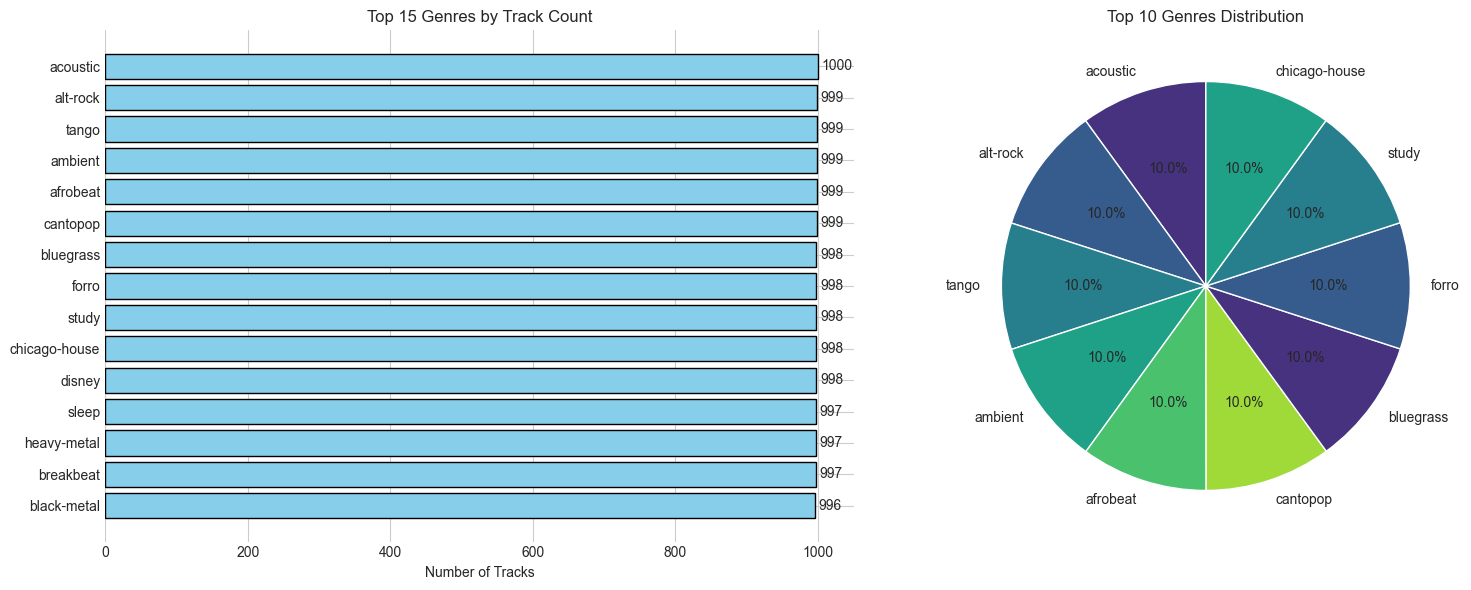


GENRE STATISTICS:
Genre with most tracks: acoustic (1000 tracks)
Genre with fewest tracks: reggaeton (74 tracks)
Average tracks per genre: 794.2
Median tracks per genre: 873.0


In [ ]:
"""
Genre Analysis
-------------------
Purpose: Analyze the distribution of tracks across different genres
"""

# Count tracks by genre
genre_counts = df_clean['track_genre'].value_counts()

print("GENRE DISTRIBUTION:")
print("="*60)
print(f"Total genres: {len(genre_counts)}")
print(f"\nTop 20 genres by number of tracks:")
print(genre_counts.head(20).to_string())

# Visualization: Top genres
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart - Top 15 genres
top_genres = genre_counts.head(15)
y_pos = range(len(top_genres))
axes[0].barh(y_pos, top_genres.values, color='skyblue', edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_genres.index)
axes[0].set_xlabel('Number of Tracks')
axes[0].set_title('Top 15 Genres by Track Count')
axes[0].invert_yaxis()

# Add value labels
for i, v in enumerate(top_genres.values):
    axes[0].text(v + 5, i, str(v), va='center')

# Pie chart - Top 10 genres
axes[1].pie(genre_counts.head(10).values, labels=genre_counts.head(10).index, 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Top 10 Genres Distribution')

plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Genre statistics
print("\nGENRE STATISTICS:")
print("="*60)
print(f"Genre with most tracks: {genre_counts.index[0]} ({genre_counts.values[0]} tracks)")
print(f"Genre with fewest tracks: {genre_counts.index[-1]} ({genre_counts.values[-1]} tracks)")
print(f"Average tracks per genre: {genre_counts.mean():.1f}")
print(f"Median tracks per genre: {genre_counts.median():.1f}")

ARTIST ANALYSIS:
Total unique artists: 31,437

Top 20 artists by number of tracks:
artists
George Jones                      260
my little airport                 171
The Beatles                       150
BTS                               143
Håkan Hellström                   141
Glee Cast                         139
Hank Williams                     136
Linkin Park                       133
Scooter                           130
OneRepublic                       124
CoComelon                         122
Ella Fitzgerald                   111
Dean Martin                       110
Arctic Monkeys                    110
Vybz Kartel                       106
Germaine Franco                   106
Charlie Brown Jr.                 106
Elvis Presley                     105
The Beach Boys                    104
Hank Williams;Drifting Cowboys    104

TOP 20 ARTISTS BY AVERAGE POPULARITY (min 5 tracks):
                   mean  count  max
artists                            
Olivia Rodrigo    87.40

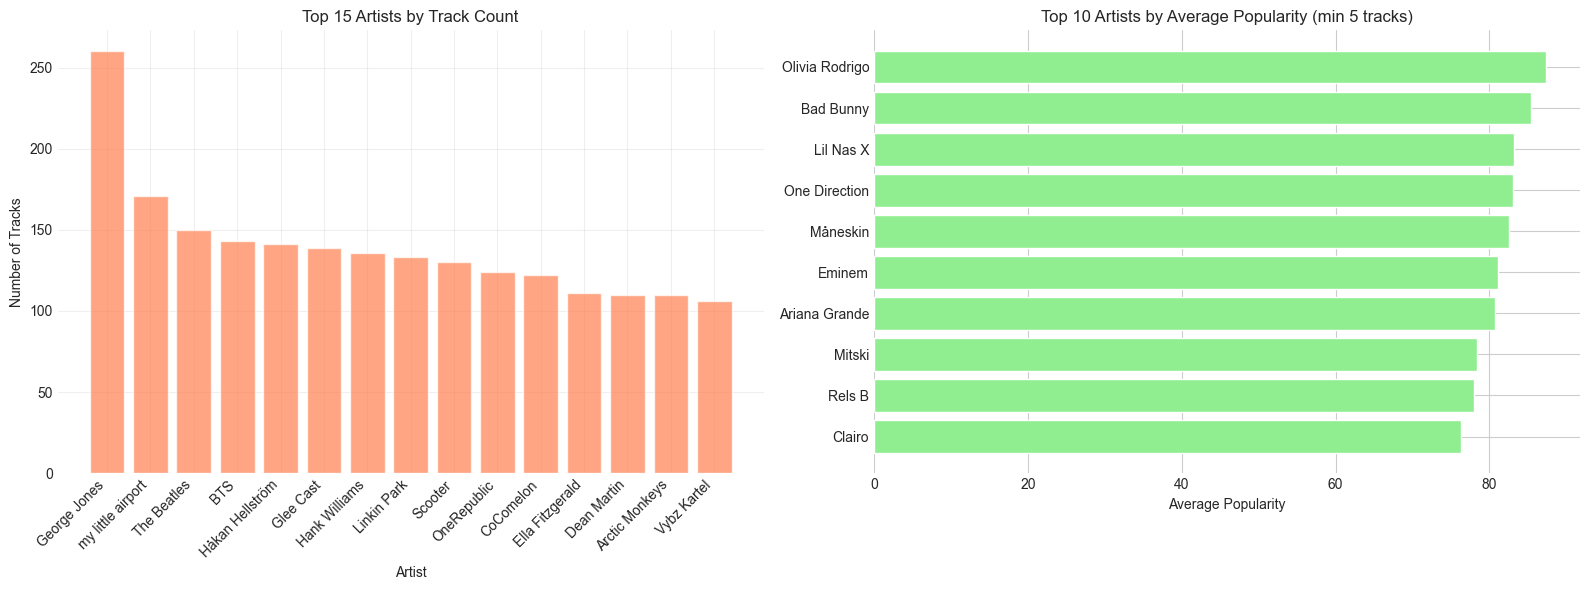

In [24]:
"""
Artist Analysis
--------------------
Purpose: Analyze the most popular and prolific artists
"""

# Count tracks by artist
artist_counts = df_clean['artists'].value_counts()

# Calculate average popularity by artist
artist_popularity = df_clean.groupby('artists')['popularity'].agg(['mean', 'count', 'max']).sort_values('mean', ascending=False)

print("ARTIST ANALYSIS:")
print("="*60)
print(f"Total unique artists: {len(artist_counts):,}")
print(f"\nTop 20 artists by number of tracks:")
print(artist_counts.head(20).to_string())

print("\nTOP 20 ARTISTS BY AVERAGE POPULARITY (min 5 tracks):")
top_popular_artists = artist_popularity[artist_popularity['count'] >= 5].head(20)
print(top_popular_artists.head(20).round(2).to_string())

# Visualization: Artist analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top artists by track count
top_artists_count = artist_counts.head(15)
axes[0].bar(range(len(top_artists_count)), top_artists_count.values, color='coral', alpha=0.7)
axes[0].set_xticks(range(len(top_artists_count)))
axes[0].set_xticklabels(top_artists_count.index, rotation=45, ha='right')
axes[0].set_xlabel('Artist')
axes[0].set_ylabel('Number of Tracks')
axes[0].set_title('Top 15 Artists by Track Count')
axes[0].grid(True, alpha=0.3)

# Top artists by popularity
top_popular_plot = top_popular_artists.head(10)
axes[1].barh(range(len(top_popular_plot)), top_popular_plot['mean'].values, color='lightgreen')
axes[1].set_yticks(range(len(top_popular_plot)))
axes[1].set_yticklabels(top_popular_plot.index)
axes[1].set_xlabel('Average Popularity')
axes[1].set_title('Top 10 Artists by Average Popularity (min 5 tracks)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('artist_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

AUDIO FEATURES CORRELATION MATRIX:
                  danceability  energy   key  loudness  mode  speechiness  \
danceability              1.00    0.14  0.04      0.27 -0.06         0.11   
energy                    0.14    1.00  0.05      0.76 -0.08         0.14   
key                       0.04    0.05  1.00      0.04 -0.14         0.02   
loudness                  0.27    0.76  0.04      1.00 -0.04         0.06   
mode                     -0.06   -0.08 -0.14     -0.04  1.00        -0.04   
speechiness               0.11    0.14  0.02      0.06 -0.04         1.00   
acousticness             -0.18   -0.73 -0.05     -0.58  0.09         0.01   
instrumentalness         -0.19   -0.18 -0.01     -0.43 -0.05        -0.10   
liveness                 -0.13    0.19 -0.00      0.08  0.02         0.23   
valence                   0.49    0.26  0.03      0.29  0.03         0.03   
tempo                    -0.02    0.26  0.01      0.23 -0.00         0.00   
popularity                0.06    0.01  0

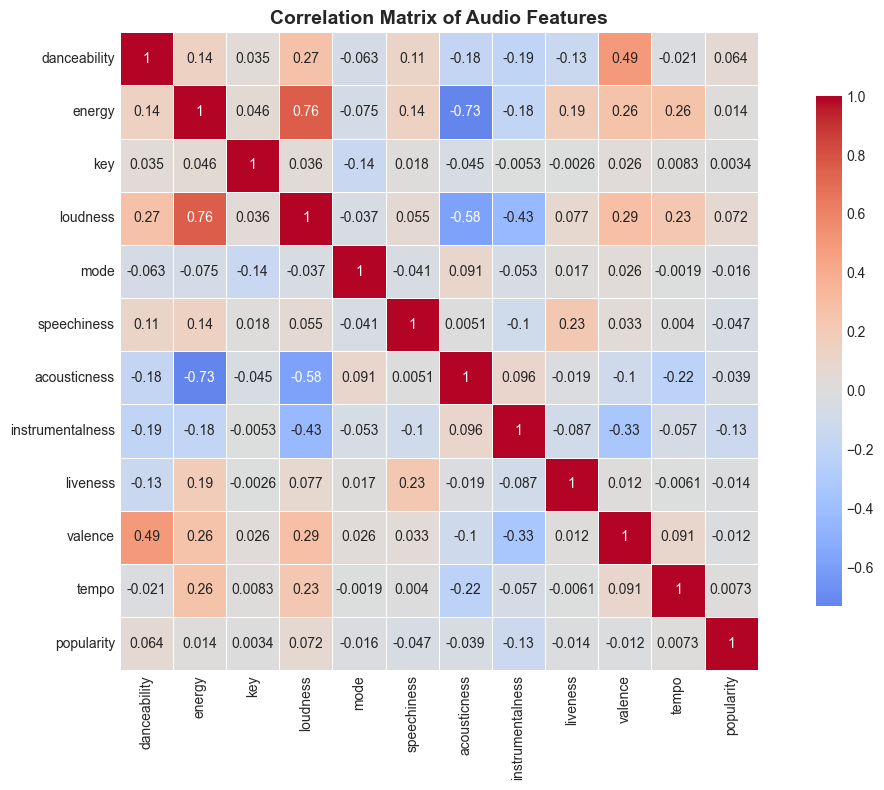


STRONGEST CORRELATIONS:
energy vs loudness: 0.759 (positive)
energy vs acousticness: -0.733 (negative)
loudness vs acousticness: -0.583 (negative)
danceability vs valence: 0.493 (positive)
loudness vs instrumentalness: -0.435 (negative)
instrumentalness vs valence: -0.331 (negative)
loudness vs valence: 0.289 (positive)
danceability vs loudness: 0.272 (positive)
energy vs tempo: 0.259 (positive)
energy vs valence: 0.256 (positive)


In [25]:
"""
Audio Features Correlation
-------------------------------
Purpose: Analyze relationships between different audio features
"""

# Select audio features for correlation
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo', 'popularity']

# Calculate correlation matrix
correlation_matrix = df_clean[audio_features].corr()

print("AUDIO FEATURES CORRELATION MATRIX:")
print("="*60)
print(correlation_matrix.round(2))

# Visualization: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Find strongest correlations
print("\nSTRONGEST CORRELATIONS:")
print("="*60)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Feature 1': correlation_matrix.columns[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs Correlation'] = abs(corr_df['Correlation'])
top_correlations = corr_df.nlargest(10, 'Abs Correlation')

for idx, row in top_correlations.iterrows():
    direction = "positive" if row['Correlation'] > 0 else "negative"
    print(f"{row['Feature 1']} vs {row['Feature 2']}: {row['Correlation']:.3f} ({direction})")

🎧 POPULARITY ANALYSIS:
Average popularity: 33.2
Median popularity: 33.0
Max popularity: 100
Min popularity: 0

POPULARITY DISTRIBUTION:
popularity
(-0.1, 10.0]     14574
(10.0, 20.0]     10518
(20.0, 30.0]     16562
(30.0, 40.0]     13471
(40.0, 50.0]     14669
(50.0, 60.0]     11112
(60.0, 70.0]      6102
(70.0, 80.0]      2233
(80.0, 90.0]       472
(90.0, 100.0]       28

TOP 10 MOST POPULAR TRACKS:
                           track_name                    artists  popularity track_genre
            Unholy (feat. Kim Petras)       Sam Smith;Kim Petras         100       dance
Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo          99     hip-hop
                      I'm Good (Blue)    David Guetta;Bebe Rexha          98       dance
                           La Bachata              Manuel Turizo          98       latin
                      Me Porto Bonito Bad Bunny;Chencho Corleone          97       latin
                     Tití Me Preguntó                  Bad B

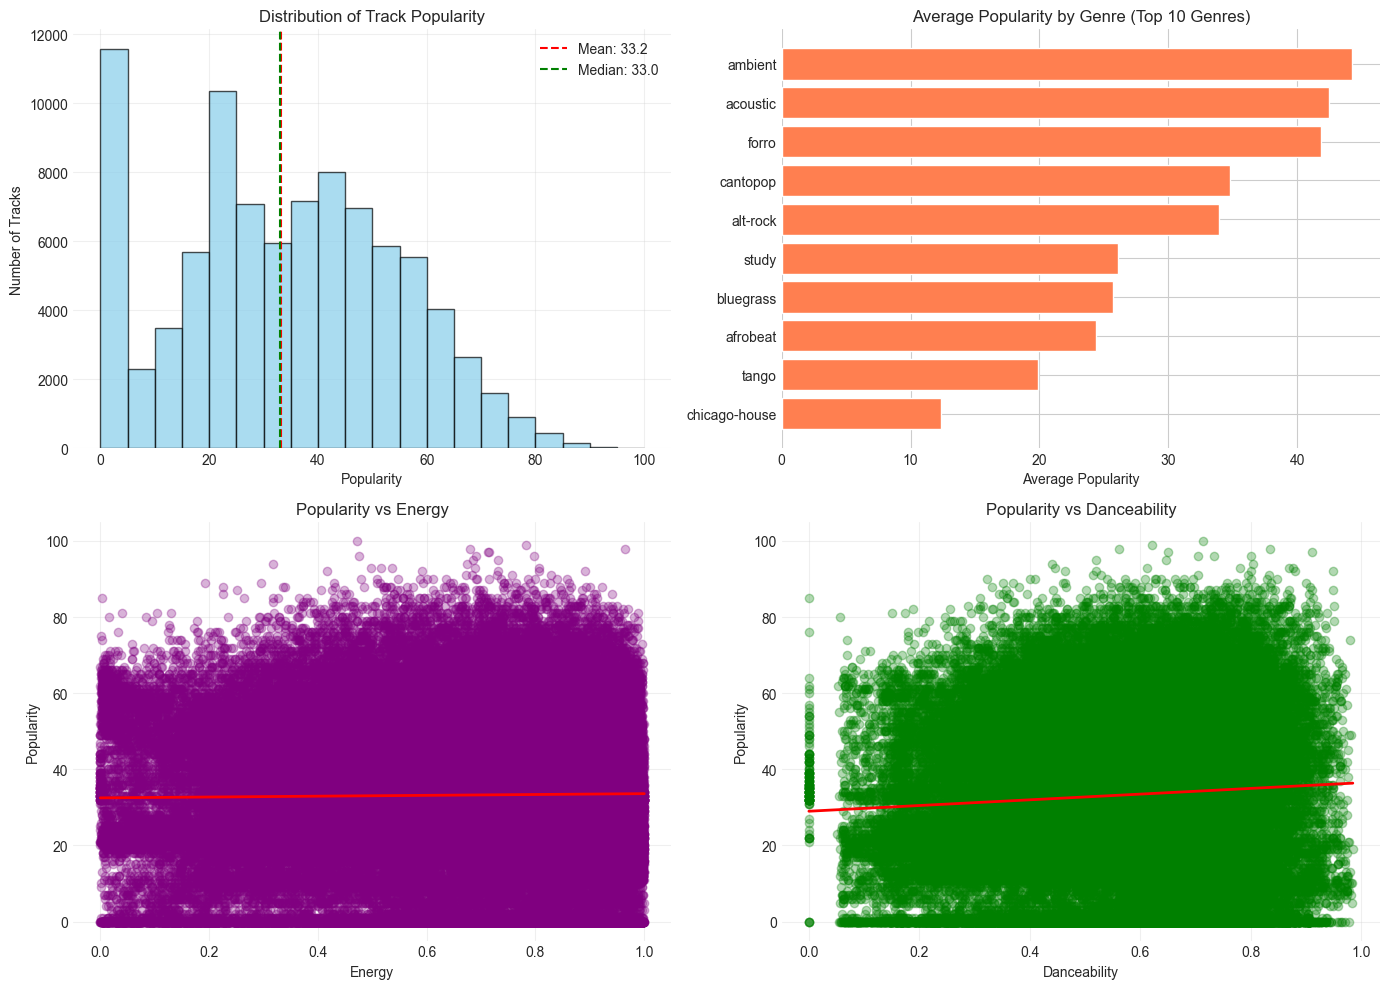

In [ ]:
"""
Track Popularity Analysis
------------------------------
Purpose: Understand what makes a track popular
"""

print("🎧 POPULARITY ANALYSIS:")
print("="*60)
print(f"Average popularity: {df_clean['popularity'].mean():.1f}")
print(f"Median popularity: {df_clean['popularity'].median():.1f}")
print(f"Max popularity: {df_clean['popularity'].max()}")
print(f"Min popularity: {df_clean['popularity'].min()}")

# Popularity distribution
print("\nPOPULARITY DISTRIBUTION:")
popularity_bins = pd.cut(df_clean['popularity'], bins=10)
popularity_dist = popularity_bins.value_counts().sort_index()
print(popularity_dist.to_string())

# Top 10 most popular tracks
print("\nTOP 10 MOST POPULAR TRACKS:")
top_tracks = df_clean.nlargest(10, 'popularity')[['track_name', 'artists', 'popularity', 'track_genre']]
print(top_tracks.to_string(index=False))

# Bottom 10 least popular tracks
print("\nBOTTOM 10 LEAST POPULAR TRACKS:")
bottom_tracks = df_clean.nsmallest(10, 'popularity')[['track_name', 'artists', 'popularity', 'track_genre']]
print(bottom_tracks.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of popularity
axes[0,0].hist(df_clean['popularity'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df_clean['popularity'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["popularity"].mean():.1f}')
axes[0,0].axvline(df_clean['popularity'].median(), color='green', linestyle='--', label=f'Median: {df_clean["popularity"].median():.1f}')
axes[0,0].set_xlabel('Popularity')
axes[0,0].set_ylabel('Number of Tracks')
axes[0,0].set_title('Distribution of Track Popularity')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Popularity by genre (top 10 genres)
top_genres_list = genre_counts.head(10).index
genre_popularity = df_clean[df_clean['track_genre'].isin(top_genres_list)].groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
axes[0,1].barh(range(len(genre_popularity)), genre_popularity.values, color='coral')
axes[0,1].set_yticks(range(len(genre_popularity)))
axes[0,1].set_yticklabels(genre_popularity.index)
axes[0,1].set_xlabel('Average Popularity')
axes[0,1].set_title('Average Popularity by Genre (Top 10 Genres)')
axes[0,1].invert_yaxis()

# Popularity vs Energy
axes[1,0].scatter(df_clean['energy'], df_clean['popularity'], alpha=0.3, color='purple')
z = np.polyfit(df_clean['energy'], df_clean['popularity'], 1)
p = np.poly1d(z)
axes[1,0].plot(df_clean['energy'].sort_values(), p(df_clean['energy'].sort_values()), color='red', linewidth=2)
axes[1,0].set_xlabel('Energy')
axes[1,0].set_ylabel('Popularity')
axes[1,0].set_title('Popularity vs Energy')
axes[1,0].grid(True, alpha=0.3)

# Popularity vs Danceability
axes[1,1].scatter(df_clean['danceability'], df_clean['popularity'], alpha=0.3, color='green')
z = np.polyfit(df_clean['danceability'], df_clean['popularity'], 1)
p = np.poly1d(z)
axes[1,1].plot(df_clean['danceability'].sort_values(), p(df_clean['danceability'].sort_values()), color='red', linewidth=2)
axes[1,1].set_xlabel('Danceability')
axes[1,1].set_ylabel('Popularity')
axes[1,1].set_title('Popularity vs Danceability')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('popularity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

AUDIO FEATURES BY GENRE (Top 10 Genres):
               danceability  energy  acousticness  valence  tempo  popularity
track_genre                                                                  
acoustic               0.55    0.43          0.57     0.42 119.01       42.48
afrobeat               0.67    0.70          0.27     0.70 119.24       24.41
alt-rock               0.54    0.75          0.12     0.52 124.65       33.90
ambient                0.37    0.24          0.78     0.17 111.16       44.21
bluegrass              0.54    0.53          0.56     0.64 126.62       25.68
cantopop               0.55    0.46          0.54     0.39 124.26       34.75
chicago-house          0.77    0.73          0.04     0.59 123.91       12.33
forro                  0.65    0.79          0.40     0.76 140.35       41.83
study                  0.69    0.41          0.53     0.40 111.82       26.13
tango                  0.54    0.37          0.85     0.58 114.53       19.87


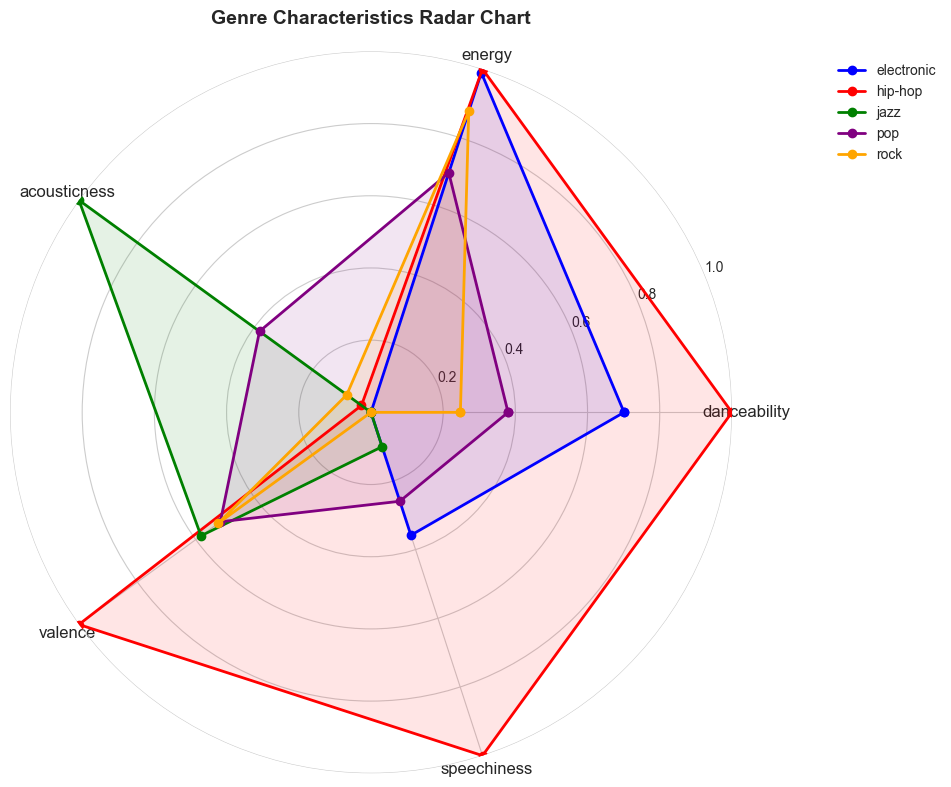

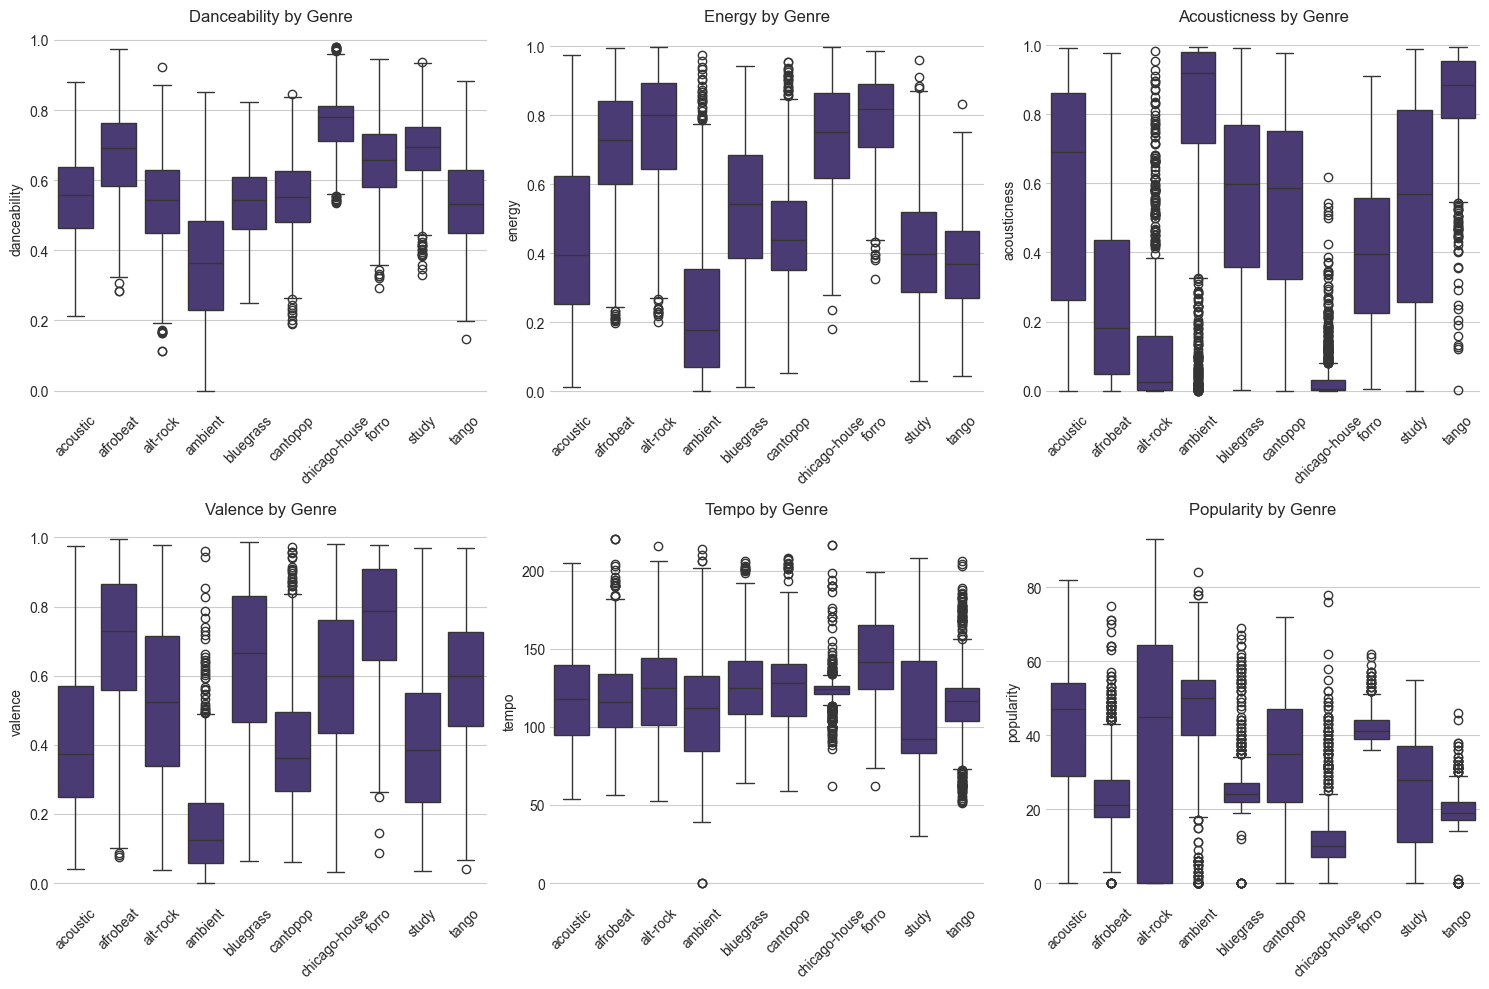

In [27]:
"""
Genre Characteristics
--------------------------
Purpose: Compare audio features across different genres
"""

# Select top 10 genres for comparison
top_10_genres = genre_counts.head(10).index.tolist()
genre_data = df_clean[df_clean['track_genre'].isin(top_10_genres)]

# Calculate average features by genre
features_by_genre = genre_data.groupby('track_genre')[['danceability', 'energy', 'acousticness', 
                                                        'valence', 'tempo', 'popularity']].mean()

print("AUDIO FEATURES BY GENRE (Top 10 Genres):")
print("="*80)
print(features_by_genre.round(3).to_string())

# Visualization: Radar chart for genre comparison
from math import pi

# Select a few genres for radar chart
selected_genres = ['pop', 'rock', 'hip-hop', 'electronic', 'jazz']
radar_data = df_clean[df_clean['track_genre'].isin(selected_genres)]

# Prepare data for radar chart
features = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness']
genre_means = radar_data.groupby('track_genre')[features].mean()

# Normalize data for radar chart
genre_means_normalized = (genre_means - genre_means.min()) / (genre_means.max() - genre_means.min())

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Number of variables
N = len(features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Plot each genre
colors = ['blue', 'red', 'green', 'purple', 'orange']
for idx, (genre, values) in enumerate(genre_means_normalized.iterrows()):
    values_list = values.values.tolist()
    values_list += values_list[:1]  # Close the loop
    ax.plot(angles, values_list, 'o-', linewidth=2, label=genre, color=colors[idx])
    ax.fill(angles, values_list, alpha=0.1, color=colors[idx])

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Genre Characteristics Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('genre_radar.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots for feature comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
feature_list = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'popularity']

for idx, feature in enumerate(feature_list):
    row = idx // 3
    col = idx % 3
    sns.boxplot(data=genre_data, x='track_genre', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature.capitalize()} by Genre')
    axes[row, col].set_xlabel('')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('genre_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

DURATION ANALYSIS:
Average duration: 3.82 minutes
Median duration: 3.55 minutes
Shortest track: 0.00 minutes
Longest track: 87.29 minutes

DURATION DISTRIBUTION:
duration_category
<2 min       5557
2-3 min     20518
3-4 min     32175
4-5 min     17924
5-10 min    13016
>10 min       535

TEMPO ANALYSIS:
Average tempo: 122.1 BPM
Median tempo: 122.0 BPM
Slowest track: 0.0 BPM
Fastest track: 243.4 BPM

TEMPO DISTRIBUTION:
tempo_category
Very Slow (<80)         6367
Slow (80-100)          16980
Medium (100-120)       18504
Fast (120-140)         24581
Very Fast (140-160)    12093
Extreme (>160)         11059


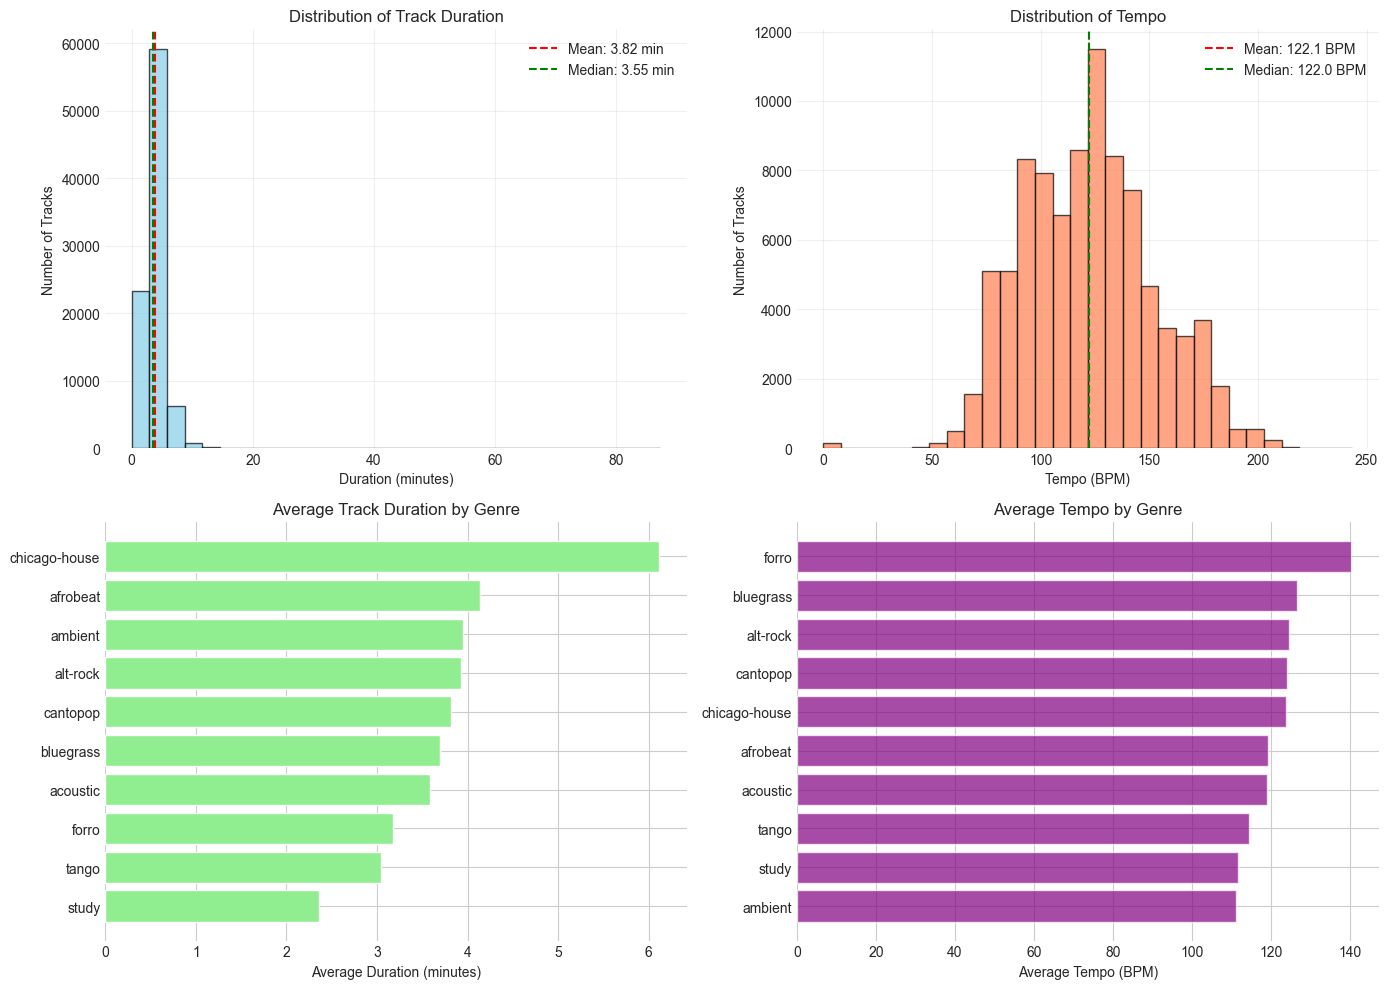

In [28]:
"""
Duration and Tempo Analysis
---------------------------------
Purpose: Analyze track duration and tempo patterns
"""

print("DURATION ANALYSIS:")
print("="*60)
print(f"Average duration: {df_clean['duration_min'].mean():.2f} minutes")
print(f"Median duration: {df_clean['duration_min'].median():.2f} minutes")
print(f"Shortest track: {df_clean['duration_min'].min():.2f} minutes")
print(f"Longest track: {df_clean['duration_min'].max():.2f} minutes")

# Duration categories
duration_bins = [0, 2, 3, 4, 5, 10, 60]
duration_labels = ['<2 min', '2-3 min', '3-4 min', '4-5 min', '5-10 min', '>10 min']
df_clean['duration_category'] = pd.cut(df_clean['duration_min'], bins=duration_bins, labels=duration_labels)
duration_dist = df_clean['duration_category'].value_counts().sort_index()

print("\nDURATION DISTRIBUTION:")
print(duration_dist.to_string())

print("\nTEMPO ANALYSIS:")
print("="*60)
print(f"Average tempo: {df_clean['tempo'].mean():.1f} BPM")
print(f"Median tempo: {df_clean['tempo'].median():.1f} BPM")
print(f"Slowest track: {df_clean['tempo'].min():.1f} BPM")
print(f"Fastest track: {df_clean['tempo'].max():.1f} BPM")

# Tempo categories
tempo_bins = [0, 80, 100, 120, 140, 160, 300]
tempo_labels = ['Very Slow (<80)', 'Slow (80-100)', 'Medium (100-120)', 
                'Fast (120-140)', 'Very Fast (140-160)', 'Extreme (>160)']
df_clean['tempo_category'] = pd.cut(df_clean['tempo'], bins=tempo_bins, labels=tempo_labels)
tempo_dist = df_clean['tempo_category'].value_counts().sort_index()

print("\nTEMPO DISTRIBUTION:")
print(tempo_dist.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration histogram
axes[0,0].hist(df_clean['duration_min'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df_clean['duration_min'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["duration_min"].mean():.2f} min')
axes[0,0].axvline(df_clean['duration_min'].median(), color='green', linestyle='--', label=f'Median: {df_clean["duration_min"].median():.2f} min')
axes[0,0].set_xlabel('Duration (minutes)')
axes[0,0].set_ylabel('Number of Tracks')
axes[0,0].set_title('Distribution of Track Duration')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Tempo histogram
axes[0,1].hist(df_clean['tempo'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0,1].axvline(df_clean['tempo'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["tempo"].mean():.1f} BPM')
axes[0,1].axvline(df_clean['tempo'].median(), color='green', linestyle='--', label=f'Median: {df_clean["tempo"].median():.1f} BPM')
axes[0,1].set_xlabel('Tempo (BPM)')
axes[0,1].set_ylabel('Number of Tracks')
axes[0,1].set_title('Distribution of Tempo')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Duration by genre
genre_duration = genre_data.groupby('track_genre')['duration_min'].mean().sort_values(ascending=False)
axes[1,0].barh(range(len(genre_duration)), genre_duration.values, color='lightgreen')
axes[1,0].set_yticks(range(len(genre_duration)))
axes[1,0].set_yticklabels(genre_duration.index)
axes[1,0].set_xlabel('Average Duration (minutes)')
axes[1,0].set_title('Average Track Duration by Genre')
axes[1,0].invert_yaxis()

# Tempo by genre
genre_tempo = genre_data.groupby('track_genre')['tempo'].mean().sort_values(ascending=False)
axes[1,1].barh(range(len(genre_tempo)), genre_tempo.values, color='purple', alpha=0.7)
axes[1,1].set_yticks(range(len(genre_tempo)))
axes[1,1].set_yticklabels(genre_tempo.index)
axes[1,1].set_xlabel('Average Tempo (BPM)')
axes[1,1].set_title('Average Tempo by Genre')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

EXPLICIT CONTENT ANALYSIS:
Explicit tracks: 7704 (8.6%)
Non-explicit tracks: 82037 (91.4%)

EXPLICIT VS NON-EXPLICIT COMPARISON:
Explicit tracks:
popularity      36.89
danceability     0.63
energy           0.72
valence          0.47
tempo          121.66
Name: True, dtype: float64

Non-explicit tracks:
popularity      32.85
danceability     0.56
energy           0.63
valence          0.47
tempo          122.10
Name: False, dtype: float64

🎵 TOP 10 GENRES WITH HIGHEST % OF EXPLICIT CONTENT:
track_genre
comedy        65.80
sad           50.40
emo           48.00
hardcore      38.40
j-dance       37.80
funk          34.70
latino        32.20
dancehall     31.40
hip-hop       31.40
alternative   31.20

🎵 TOP 10 GENRES WITH LOWEST % OF EXPLICIT CONTENT:
track_genre
children      0.00
classical     0.00
gospel        0.00
honky-tonk    0.00
jazz          0.00
opera         0.00
sleep         0.00
study         0.00
tango         0.00
world-music   0.00


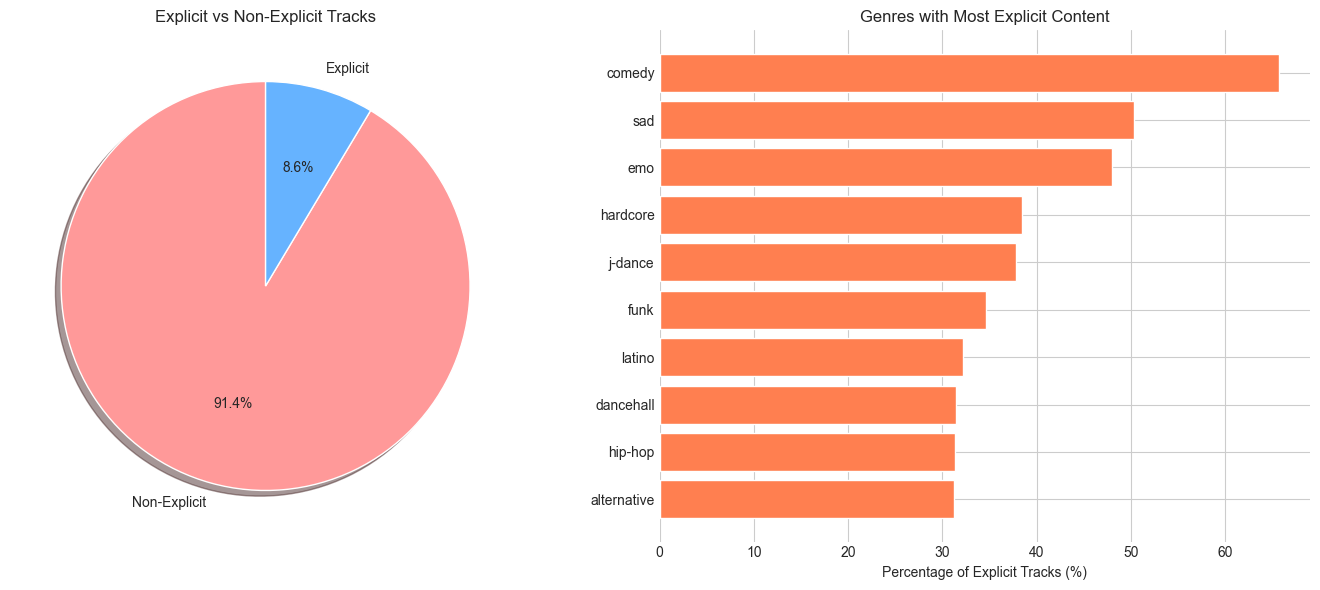

In [29]:
"""
Explicit Content Analysis
-------------------------------
Purpose: Analyze explicit vs non-explicit tracks
"""

# Explicit vs Non-explicit counts
explicit_counts = df_clean['explicit'].value_counts()
explicit_percent = (explicit_counts / len(df_clean)) * 100

print("EXPLICIT CONTENT ANALYSIS:")
print("="*60)
print(f"Explicit tracks: {explicit_counts.get(True, 0)} ({explicit_percent.get(True, 0):.1f}%)")
print(f"Non-explicit tracks: {explicit_counts.get(False, 0)} ({explicit_percent.get(False, 0):.1f}%)")

# Compare features of explicit vs non-explicit
explicit_comparison = df_clean.groupby('explicit')[['popularity', 'danceability', 'energy', 
                                                    'valence', 'tempo']].mean()

print("\nEXPLICIT VS NON-EXPLICIT COMPARISON:")
print("="*60)
print("Explicit tracks:")
print(explicit_comparison.loc[True].round(2) if True in explicit_comparison.index else "No explicit tracks")
print("\nNon-explicit tracks:")
print(explicit_comparison.loc[False].round(2) if False in explicit_comparison.index else "No non-explicit tracks")

# Explicit by genre
explicit_by_genre = df_clean.groupby('track_genre')['explicit'].mean() * 100
top_explicit_genres = explicit_by_genre.nlargest(10)
bottom_explicit_genres = explicit_by_genre.nsmallest(10)

print("\n🎵 TOP 10 GENRES WITH HIGHEST % OF EXPLICIT CONTENT:")
print(top_explicit_genres.round(1).to_string())

print("\n🎵 TOP 10 GENRES WITH LOWEST % OF EXPLICIT CONTENT:")
print(bottom_explicit_genres.round(1).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Explicit vs Non-explicit pie chart
colors = ['#ff9999', '#66b3ff']
axes[0].pie(explicit_counts.values, labels=['Explicit' if i else 'Non-Explicit' for i in explicit_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=colors, shadow=True)
axes[0].set_title('Explicit vs Non-Explicit Tracks')

# Explicit by genre (top 10)
axes[1].barh(range(len(top_explicit_genres)), top_explicit_genres.values, color='coral')
axes[1].set_yticks(range(len(top_explicit_genres)))
axes[1].set_yticklabels(top_explicit_genres.index)
axes[1].set_xlabel('Percentage of Explicit Tracks (%)')
axes[1].set_title('Genres with Most Explicit Content')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('explicit_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

MOOD ANALYSIS (Based on Valence):
Average valence: 0.469
Median valence: 0.457
Happiest track valence: 0.995
Saddest track valence: 0.000

Happy tracks (valence > 0.5): 40384 (45.0%)
Sad/Melancholic tracks (valence ≤ 0.5): 49357 (55.0%)

TOP 10 HAPPIEST TRACKS:
               track_name                                      artists  valence  energy  danceability
             The Demander                                  Victor Rice     0.99    0.79          0.68
           Flor de Capomo Julio Preciado Y Su Banda Perla Del Pacifico     0.99    0.70          0.74
                   Zuipen                                   Lawineboys     0.99    0.87          0.85
          Roll Your Hands                                   Debbie Doo     0.99    0.70          0.74
Hands Up - Single Version                                      Ottawan     0.99    0.88          0.89
           I Like Pencils          Cody;Heart;Mr. Primm;Scatter;K.Flay     0.99    0.45          0.96
              Tell Me No

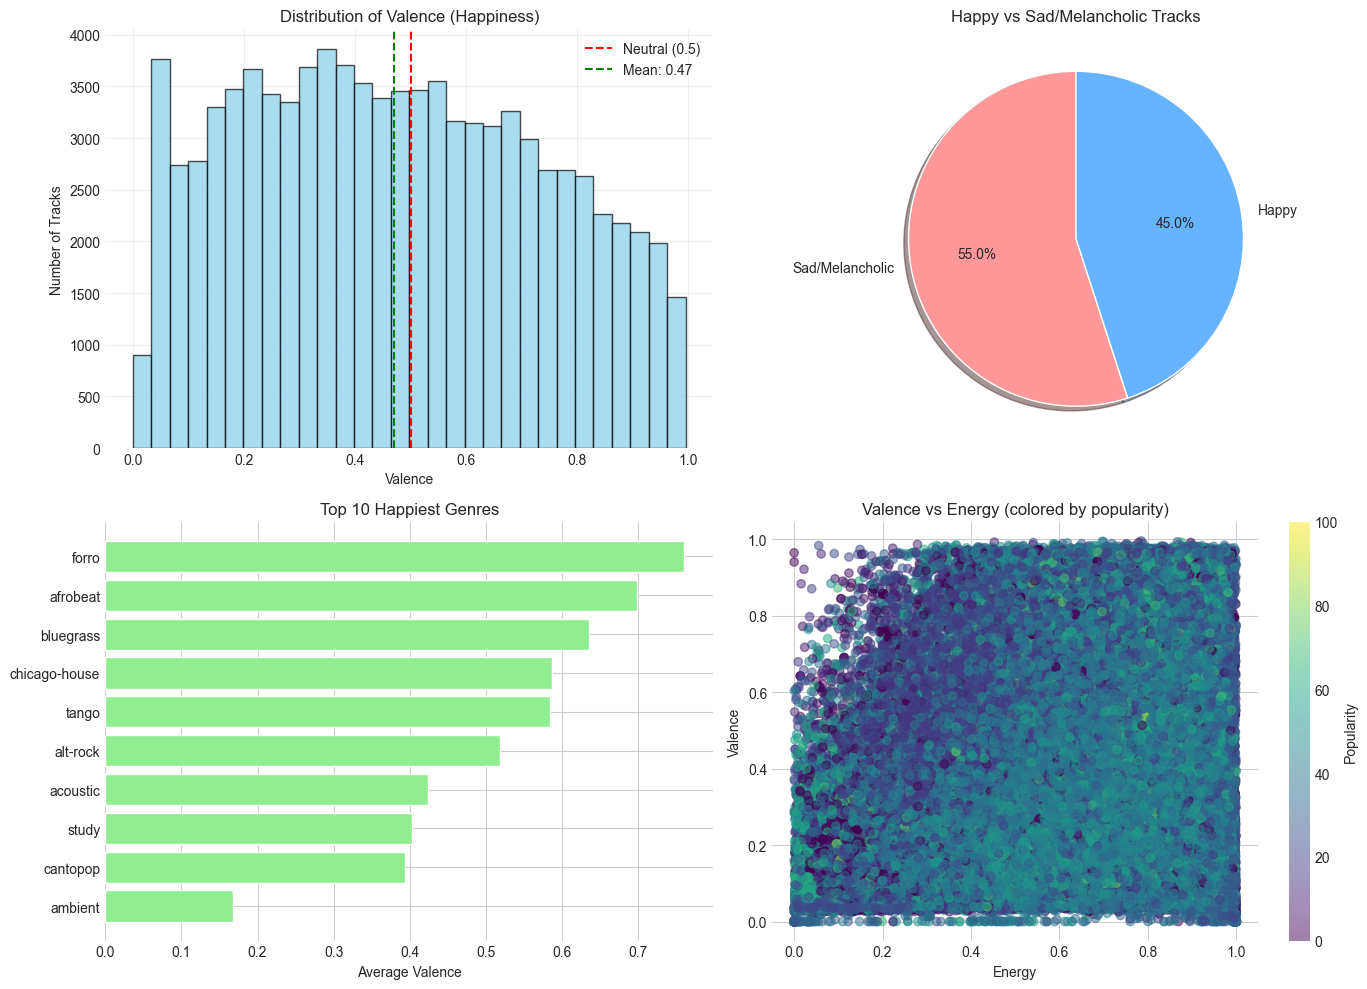

In [30]:
"""
Mood Analysis - Happy vs Sad Songs
----------------------------------------
Purpose: Analyze the emotional content of tracks based on valence
"""

print("MOOD ANALYSIS (Based on Valence):")
print("="*60)
print(f"Average valence: {df_clean['valence'].mean():.3f}")
print(f"Median valence: {df_clean['valence'].median():.3f}")
print(f"Happiest track valence: {df_clean['valence'].max():.3f}")
print(f"Saddest track valence: {df_clean['valence'].min():.3f}")

# Mood distribution
mood_counts = df_clean['mood'].value_counts()
mood_percent = (mood_counts / len(df_clean)) * 100

print(f"\nHappy tracks (valence > 0.5): {mood_counts.get('Happy', 0)} ({mood_percent.get('Happy', 0):.1f}%)")
print(f"Sad/Melancholic tracks (valence ≤ 0.5): {mood_counts.get('Sad/Melancholic', 0)} ({mood_percent.get('Sad/Melancholic', 0):.1f}%)")

# Top happiest tracks
print("\nTOP 10 HAPPIEST TRACKS:")
happiest = df_clean.nlargest(10, 'valence')[['track_name', 'artists', 'valence', 'energy', 'danceability']]
print(happiest.to_string(index=False))

# Top saddest tracks
print("\nTOP 10 SADDEST TRACKS:")
saddest = df_clean.nsmallest(10, 'valence')[['track_name', 'artists', 'valence', 'energy', 'danceability']]
print(saddest.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Valence distribution
axes[0,0].hist(df_clean['valence'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(0.5, color='red', linestyle='--', label='Neutral (0.5)')
axes[0,0].axvline(df_clean['valence'].mean(), color='green', linestyle='--', label=f'Mean: {df_clean["valence"].mean():.2f}')
axes[0,0].set_xlabel('Valence')
axes[0,0].set_ylabel('Number of Tracks')
axes[0,0].set_title('Distribution of Valence (Happiness)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Mood pie chart
axes[0,1].pie(mood_counts.values, labels=mood_counts.index, autopct='%1.1f%%', 
              colors=['#ff9999', '#66b3ff'], startangle=90, shadow=True)
axes[0,1].set_title('Happy vs Sad/Melancholic Tracks')

# Valence by genre
valence_by_genre = genre_data.groupby('track_genre')['valence'].mean().sort_values(ascending=False)
axes[1,0].barh(range(len(valence_by_genre.head(10))), valence_by_genre.head(10).values, color='lightgreen')
axes[1,0].set_yticks(range(len(valence_by_genre.head(10))))
axes[1,0].set_yticklabels(valence_by_genre.head(10).index)
axes[1,0].set_xlabel('Average Valence')
axes[1,0].set_title('Top 10 Happiest Genres')
axes[1,0].invert_yaxis()

# Valence vs Energy scatter
scatter = axes[1,1].scatter(df_clean['energy'], df_clean['valence'], 
                            c=df_clean['popularity'], cmap='viridis', alpha=0.5)
axes[1,1].set_xlabel('Energy')
axes[1,1].set_ylabel('Valence')
axes[1,1].set_title('Valence vs Energy (colored by popularity)')
plt.colorbar(scatter, ax=axes[1,1], label='Popularity')

plt.tight_layout()
plt.savefig('mood_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

KEY ANALYSIS:
Key A:  8,998 tracks (10.0%)
Key A#/Bb:  5,889 tracks (6.6%)
Key B:  7,129 tracks (7.9%)
Key C: 10,352 tracks (11.5%)
Key C#/Db:  8,576 tracks (9.6%)
Key D:  9,327 tracks (10.4%)
Key D#/Eb:  2,769 tracks (3.1%)
Key E:  7,133 tracks (7.9%)
Key F:  7,308 tracks (8.1%)
Key F#/Gb:  6,139 tracks (6.8%)
Key G: 10,551 tracks (11.8%)
Key G#/Ab:  5,570 tracks (6.2%)

🎼 MODE ANALYSIS:
Major: 57,162 tracks (63.7%)
Minor: 32,579 tracks (36.3%)

AVERAGE POPULARITY BY KEY:
key_name
E       34.10
B       33.90
G#/Ab   33.80
D       33.70
F#/Gb   33.50
D#/Eb   33.20
F       33.00
A       32.90
C#/Db   32.90
A#/Bb   32.80
C       32.70
G       32.60

AVERAGE POPULARITY BY MODE:
mode_name
Major   32.90
Minor   33.60


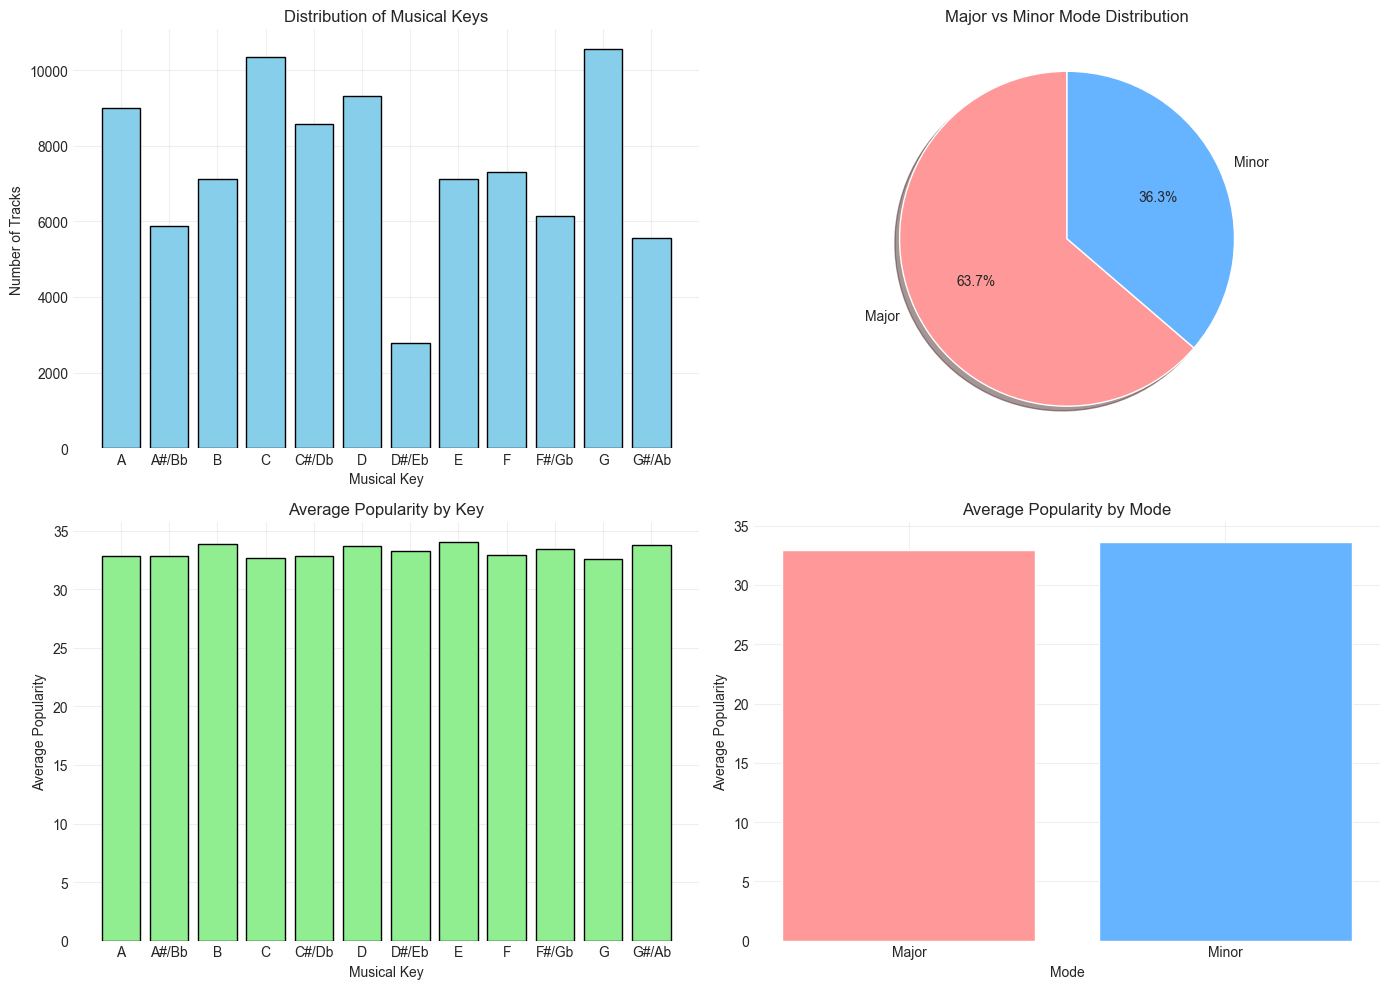

In [ ]:
"""
Musical Key and Mode Analysis
-----------------------------------
Purpose: Analyze distribution of musical keys and modes
"""

# Map key numbers to note names
key_names = {
    0: 'C', 1: 'C#/Db', 2: 'D', 3: 'D#/Eb', 4: 'E', 5: 'F',
    6: 'F#/Gb', 7: 'G', 8: 'G#/Ab', 9: 'A', 10: 'A#/Bb', 11: 'B'
}
df_clean['key_name'] = df_clean['key'].map(key_names)

# Mode mapping (0 = minor, 1 = major)
df_clean['mode_name'] = df_clean['mode'].map({0: 'Minor', 1: 'Major'})

print("KEY ANALYSIS:")
print("="*60)
key_counts = df_clean['key_name'].value_counts().sort_index()
for key in sorted(key_names.values()):
    count = key_counts.get(key, 0)
    percentage = (count / len(df_clean)) * 100
    print(f"Key {key}: {count:6,d} tracks ({percentage:.1f}%)")

print("\n MODE ANALYSIS:")
print("="*60)
mode_counts = df_clean['mode_name'].value_counts()
for mode, count in mode_counts.items():
    percentage = (count / len(df_clean)) * 100
    print(f"{mode}: {count:6,d} tracks ({percentage:.1f}%)")

# Popularity by key and mode
key_popularity = df_clean.groupby('key_name')['popularity'].mean().sort_values(ascending=False)
mode_popularity = df_clean.groupby('mode_name')['popularity'].mean()

print("\nAVERAGE POPULARITY BY KEY:")
print(key_popularity.round(1).to_string())

print("\nAVERAGE POPULARITY BY MODE:")
print(mode_popularity.round(1).to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Key distribution
keys_sorted = sorted(key_names.values())
key_counts_sorted = [key_counts.get(k, 0) for k in keys_sorted]
axes[0,0].bar(keys_sorted, key_counts_sorted, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Musical Key')
axes[0,0].set_ylabel('Number of Tracks')
axes[0,0].set_title('Distribution of Musical Keys')
axes[0,0].grid(True, alpha=0.3)

# Mode distribution
axes[0,1].pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%', 
              colors=['#ff9999', '#66b3ff'], startangle=90, shadow=True)
axes[0,1].set_title('Major vs Minor Mode Distribution')

# Popularity by key
key_pop_sorted = key_popularity.reindex(keys_sorted)
axes[1,0].bar(keys_sorted, key_pop_sorted.values, color='lightgreen', edgecolor='black')
axes[1,0].set_xlabel('Musical Key')
axes[1,0].set_ylabel('Average Popularity')
axes[1,0].set_title('Average Popularity by Key')
axes[1,0].grid(True, alpha=0.3)

# Popularity by mode
axes[1,1].bar(mode_popularity.index, mode_popularity.values, color=['#ff9999', '#66b3ff'])
axes[1,1].set_xlabel('Mode')
axes[1,1].set_ylabel('Average Popularity')
axes[1,1].set_title('Average Popularity by Mode')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('key_mode_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

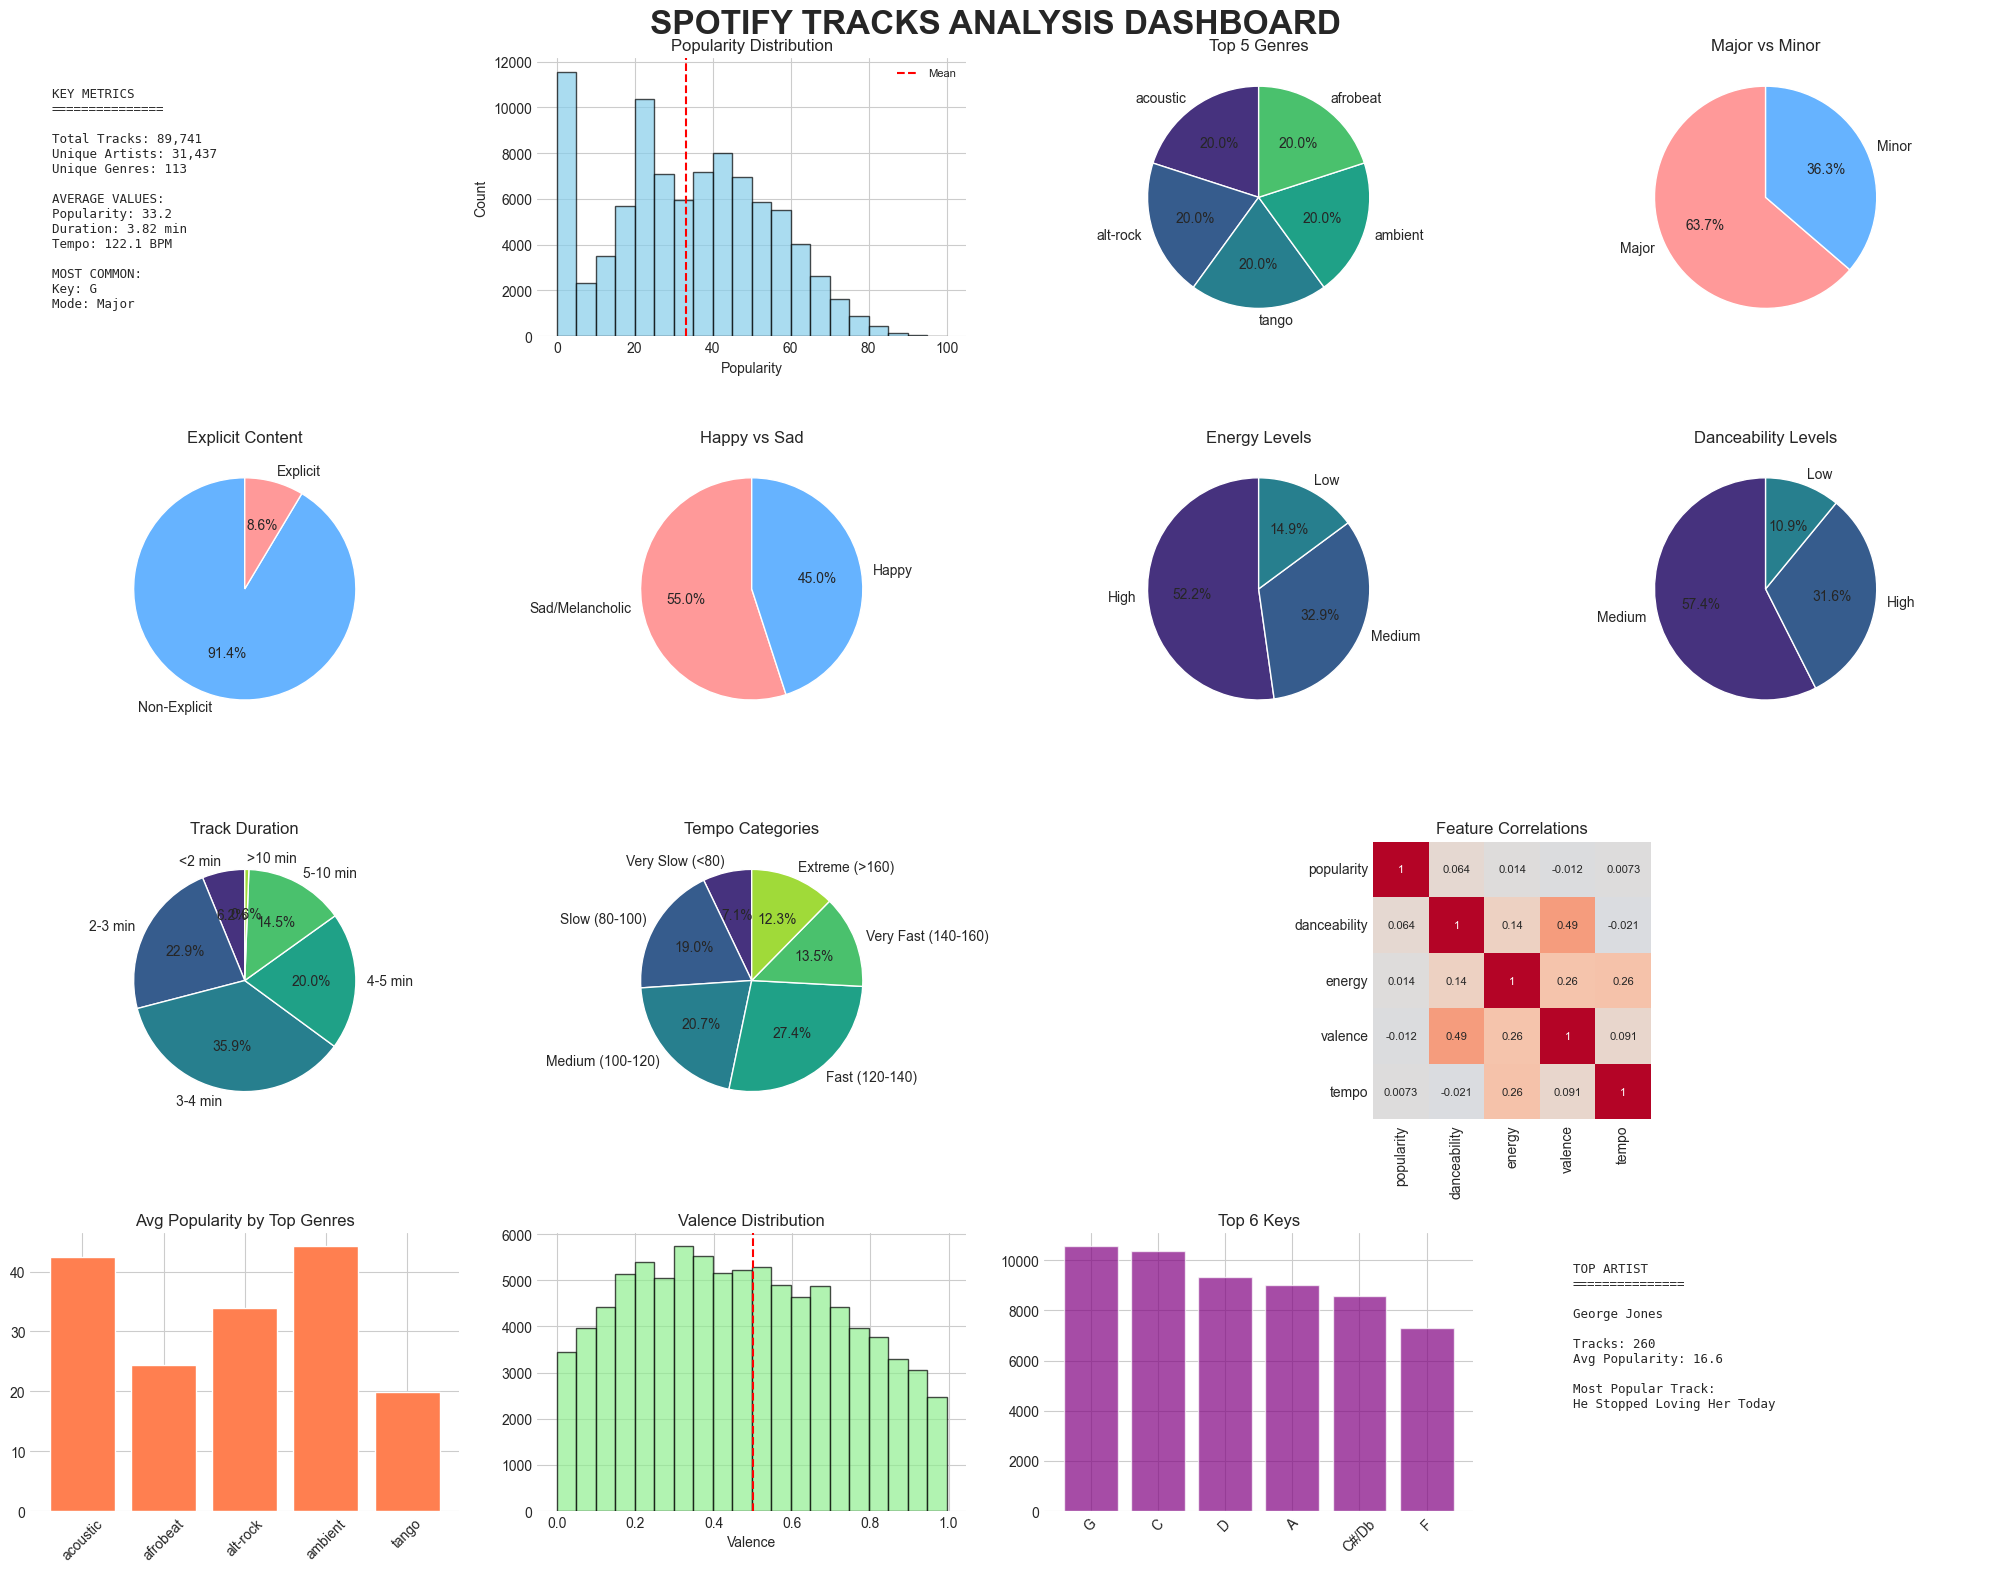


EXECUTIVE DASHBOARD COMPLETE! Check 'spotify_dashboard.png'


In [32]:
"""
Executive Summary Dashboard
---------------------------------
Purpose: Create a comprehensive dashboard of all key insights
"""

fig = plt.figure(figsize=(20, 16))
fig.suptitle('SPOTIFY TRACKS ANALYSIS DASHBOARD', fontsize=24, fontweight='bold', y=0.98)

# 1. Key Metrics Panel
ax1 = plt.subplot(4, 4, 1)
ax1.axis('off')
metrics_text = f"""
KEY METRICS
{'='*15}

Total Tracks: {len(df_clean):,}
Unique Artists: {df_clean['artists'].nunique():,}
Unique Genres: {df_clean['track_genre'].nunique():,}

AVERAGE VALUES:
Popularity: {df_clean['popularity'].mean():.1f}
Duration: {df_clean['duration_min'].mean():.2f} min
Tempo: {df_clean['tempo'].mean():.1f} BPM

MOST COMMON:
Key: {df_clean['key_name'].mode()[0]}
Mode: {df_clean['mode_name'].mode()[0]}
"""
ax1.text(0.05, 0.95, metrics_text, fontsize=9, verticalalignment='top', fontfamily='monospace', transform=ax1.transAxes)

# 2. Popularity Distribution
ax2 = plt.subplot(4, 4, 2)
ax2.hist(df_clean['popularity'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(df_clean['popularity'].mean(), color='red', linestyle='--', label=f'Mean')
ax2.set_title('Popularity Distribution')
ax2.set_xlabel('Popularity')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

# 3. Top Genres
ax3 = plt.subplot(4, 4, 3)
top_genres_pie = genre_counts.head(5)
ax3.pie(top_genres_pie.values, labels=top_genres_pie.index, autopct='%1.1f%%', startangle=90)
ax3.set_title('Top 5 Genres')

# 4. Mode Distribution
ax4 = plt.subplot(4, 4, 4)
mode_pie = df_clean['mode_name'].value_counts()
ax4.pie(mode_pie.values, labels=mode_pie.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
ax4.set_title('Major vs Minor')

# 5. Explicit Content
ax5 = plt.subplot(4, 4, 5)
explicit_pie = df_clean['explicit'].value_counts()
labels = ['Non-Explicit' if not i else 'Explicit' for i in explicit_pie.index]
ax5.pie(explicit_pie.values, labels=labels, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
ax5.set_title('Explicit Content')

# 6. Mood Distribution
ax6 = plt.subplot(4, 4, 6)
mood_pie = df_clean['mood'].value_counts()
ax6.pie(mood_pie.values, labels=mood_pie.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
ax6.set_title('Happy vs Sad')

# 7. Energy Levels
ax7 = plt.subplot(4, 4, 7)
energy_pie = df_clean['energy_level'].value_counts()
ax7.pie(energy_pie.values, labels=energy_pie.index, autopct='%1.1f%%', startangle=90)
ax7.set_title('Energy Levels')

# 8. Danceability Levels
ax8 = plt.subplot(4, 4, 8)
dance_pie = df_clean['danceability_level'].value_counts()
ax8.pie(dance_pie.values, labels=dance_pie.index, autopct='%1.1f%%', startangle=90)
ax8.set_title('Danceability Levels')

# 9. Duration Categories
ax9 = plt.subplot(4, 4, 9)
duration_pie = df_clean['duration_category'].value_counts().sort_index()
ax9.pie(duration_pie.values, labels=duration_pie.index, autopct='%1.1f%%', startangle=90)
ax9.set_title('Track Duration')

# 10. Tempo Categories
ax10 = plt.subplot(4, 4, 10)
tempo_pie = df_clean['tempo_category'].value_counts().sort_index()
ax10.pie(tempo_pie.values, labels=tempo_pie.index, autopct='%1.1f%%', startangle=90)
ax10.set_title('Tempo Categories')

# 11. Correlation Heatmap (small)
ax11 = plt.subplot(4, 4, (11, 12))
small_corr = df_clean[['popularity', 'danceability', 'energy', 'valence', 'tempo']].corr()
sns.heatmap(small_corr, annot=True, cmap='coolwarm', center=0, square=True, 
            cbar=False, ax=ax11, annot_kws={'size': 8})
ax11.set_title('Feature Correlations')

# 12. Popularity by Genre (Top 5)
ax12 = plt.subplot(4, 4, 13)
top_5_genres = genre_counts.head(5).index
pop_by_genre = df_clean[df_clean['track_genre'].isin(top_5_genres)].groupby('track_genre')['popularity'].mean()
ax12.bar(pop_by_genre.index, pop_by_genre.values, color='coral')
ax12.set_title('Avg Popularity by Top Genres')
ax12.tick_params(axis='x', rotation=45)

# 13. Valence Distribution
ax13 = plt.subplot(4, 4, 14)
ax13.hist(df_clean['valence'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
ax13.axvline(0.5, color='red', linestyle='--')
ax13.set_title('Valence Distribution')
ax13.set_xlabel('Valence')

# 14. Key Distribution (simplified)
ax14 = plt.subplot(4, 4, 15)
top_keys = df_clean['key_name'].value_counts().head(6)
ax14.bar(top_keys.index, top_keys.values, color='purple', alpha=0.7)
ax14.set_title('Top 6 Keys')
ax14.tick_params(axis='x', rotation=45)

# 15. Top Artist
ax15 = plt.subplot(4, 4, 16)
ax15.axis('off')
top_artist = artist_counts.index[0]
top_artist_tracks = artist_counts.values[0]
top_artist_pop = df_clean[df_clean['artists'] == top_artist]['popularity'].mean()
artist_text = f"""
TOP ARTIST
{'='*15}

{top_artist}

Tracks: {top_artist_tracks:,}
Avg Popularity: {top_artist_pop:.1f}

Most Popular Track:
{df_clean[df_clean['artists'] == top_artist].nlargest(1, 'popularity')['track_name'].values[0]}
"""
ax15.text(0.05, 0.95, artist_text, fontsize=9, verticalalignment='top', fontfamily='monospace', transform=ax15.transAxes)

plt.tight_layout()
plt.savefig('spotify_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEXECUTIVE DASHBOARD COMPLETE! Check 'spotify_dashboard.png'")

In [33]:
"""
Export Analysis Results
-----------------------------
Purpose: Save your work for portfolio presentation
"""

# Save cleaned data
df_clean.to_csv('cleaned_spotify_data.csv', index=False)
print("Cleaned data saved to 'cleaned_spotify_data.csv'")

# Save summary statistics
with open('spotify_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("SPOTIFY TRACKS ANALYSIS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("DATASET OVERVIEW\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total Tracks: {len(df_clean):,}\n")
    f.write(f"Total Artists: {df_clean['artists'].nunique():,}\n")
    f.write(f"Total Genres: {df_clean['track_genre'].nunique():,}\n\n")
    
    f.write("AUDIO FEATURES (AVERAGES)\n")
    f.write("-" * 40 + "\n")
    f.write(f"Popularity: {df_clean['popularity'].mean():.1f}\n")
    f.write(f"Duration: {df_clean['duration_min'].mean():.2f} minutes\n")
    f.write(f"Danceability: {df_clean['danceability'].mean():.3f}\n")
    f.write(f"Energy: {df_clean['energy'].mean():.3f}\n")
    f.write(f"Valence: {df_clean['valence'].mean():.3f}\n")
    f.write(f"Tempo: {df_clean['tempo'].mean():.1f} BPM\n\n")
    
    f.write("TOP GENRES\n")
    f.write("-" * 40 + "\n")
    for genre, count in genre_counts.head(10).items():
        f.write(f"{genre:20s}: {count:6,d} tracks\n")
    
    f.write("\nTOP ARTISTS\n")
    f.write("-" * 40 + "\n")
    for artist, count in artist_counts.head(10).items():
        f.write(f"{artist[:30]:30s}: {count:4,d} tracks\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("Analysis generated on: " + pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")

print("Summary saved to 'spotify_summary.txt'")



Cleaned data saved to 'cleaned_spotify_data.csv'
Summary saved to 'spotify_summary.txt'
